# 07 — Faz 5b: Renk Zenginleştirmesi (`set_colors.csv`)

**Amaç:** `inventory_parts.csv` (~133 MB) ile `colors.csv`'yi birleştirip **set başına renk özet
tablosu** üretmek. Bu tablo Bölüm 2 EDA'sında (renk çeşitliliği fiyatla ilişkili mi?) ve ileride
Bölüm 3'te (renk paleti evrimi) kullanılacak.

Join zinciri, [01_data_quality_check.ipynb](01_data_quality_check.ipynb) §10 ve
[03_add_minifig_count.ipynb](03_add_minifig_count.ipynb) ile aynı:

```
set_num --(inventories.csv, en güncel version)--> inventory_id --(inventory_parts.csv, is_spare=False)--> color_id --(colors.csv)--> name, is_trans
```

Envanter eşleştirmesi artık `src/rebrickable.py`'deki `latest_inventory()` fonksiyonunda; 01 ve 03
notebook'ları kendi kopyalarını kullanmaya devam ediyor (03 `sets_clean.csv`'yi yerinde güncellediği
için yeniden çalıştırılması güvenli değil — o yüzden dokunulmadı).

**Kararlar:**
- **Spare parçalar hariç** (`is_spare=False`): §10'da `num_parts`'ın spare parçaları içermediği
  doğrulandı; setin "asıl" görünümünü temsil etmiyorlar.
- **Birim = parça adedi** (`quantity` toplamı), satır sayısı değil: 20 adet siyah 1x2 tuğla, tek
  satır olsa da 20 parça olarak sayılıyor.
- **Minifig parçaları bu tabloda yok:** setin kendi envanteri minifiglerin parçalarını içermiyor
  (onlar ayrı `fig-...` envanterlerinde). Etkisi §6'da ölçülüyor.

In [1]:
import resource
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "../src")
from rebrickable import latest_inventory, read_inventory_parts

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RAW = "../data/raw"
PROCESSED = "../data/processed"


def peak_rss_mb() -> float:
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024 / 1024  # macOS: byte cinsinden

## 1. Veriyi oku

In [2]:
t0 = time.perf_counter()
inventory_parts = read_inventory_parts(RAW)
read_seconds = time.perf_counter() - t0

colors = pd.read_csv(f"{RAW}/colors.csv", usecols=["id", "name", "rgb", "is_trans"])
inventories = pd.read_csv(f"{RAW}/inventories.csv")
sets_clean = pd.read_csv(f"{PROCESSED}/sets_clean.csv")

print(f"inventory_parts.csv: {len(inventory_parts):,} satır — {read_seconds:.2f} sn, "
      f"bellekte {inventory_parts.memory_usage(deep=True).sum() / 1e6:.0f} MB")
print(f"colors.csv         : {len(colors):,} renk ({colors['is_trans'].sum()} şeffaf)")
print(f"inventories.csv    : {len(inventories):,} envanter")
print(f"sets_clean.csv     : {len(sets_clean):,} set ({sets_clean['is_analysis_ready'].sum():,} analiz-hazır)")
print(f"Süreç tepe belleği şu ana kadar: {peak_rss_mb():.0f} MB")
inventory_parts.head(3)

inventory_parts.csv: 1,556,894 satır — 0.34 sn, bellekte 17 MB
colors.csv         : 275 renk (46 şeffaf)
inventories.csv    : 47,339 envanter
sets_clean.csv     : 18,899 set (18,190 analiz-hazır)
Süreç tepe belleği şu ana kadar: 197 MB


,inventory_id,color_id,quantity,is_spare
0,1,72,1,False
1,1,0,1,False
2,1,7,1,False


**Bellek notu:** Dosyanın tamamı (`img_url` ve `part_num` dahil) okunduğunda ~293 MB bellek tutuyor;
`read_inventory_parts()` sadece gereken 4 kolonu dar tiplerle (`int32`/`int16`/`bool`) okuyarak bunu
~17 MB'a indiriyor. 24 GB RAM'li makinede chunk'lı okumaya gerek kalmadı.

## 2. `set_num` ↔ `inventory_id` (en güncel version)

In [3]:
latest = latest_inventory(inventories)

n_multi_version = (inventories.groupby("set_num").size() > 1).sum()
print(f"Birden fazla envanter versiyonu olan set: {n_multi_version:,} / {inventories['set_num'].nunique():,}")
print(f"En güncel envanter tablosu: {len(latest):,} satır (03 notebook'u ile aynı olmalı: 45,403)")
assert latest["set_num"].is_unique
assert len(latest) == 45_403

Birden fazla envanter versiyonu olan set: 1,280 / 45,403
En güncel envanter tablosu: 45,403 satır (03 notebook'u ile aynı olmalı: 45,403)


## 3. Parça–renk tablosu (spare hariç)

In [4]:
n_spare = inventory_parts["is_spare"].sum()
parts = (
    inventory_parts[~inventory_parts["is_spare"]]
    .merge(latest, on="inventory_id", how="inner")  # eski envanter versiyonlarının satırları düşer
    .merge(colors.rename(columns={"id": "color_id", "name": "color_name"}), on="color_id", how="left")
)

print(f"Spare olarak çıkarılan satır: {n_spare:,} ({n_spare / len(inventory_parts):.1%})")
print(f"En güncel envantere ait, spare olmayan satır: {len(parts):,}")
print(f"Toplam parça adedi: {parts['quantity'].sum():,}")
assert parts["color_name"].notna().all(), "colors.csv'de karşılığı olmayan color_id var"
print("✅ Tüm color_id'ler colors.csv'de eşleşti")

Spare olarak çıkarılan satır: 110,454 (7.1%)
En güncel envantere ait, spare olmayan satır: 1,327,254
Toplam parça adedi: 4,624,111
✅ Tüm color_id'ler colors.csv'de eşleşti


## 4. Set başına renk metrikleri

- `n_unique_colors`: farklı renk sayısı (`[Unknown]` rengi de bir renk olarak sayılıyor — çok nadir)
- `dominant_color_name`: toplam `quantity`'si en yüksek renk (eşitlikte alfabetik ilk renk, tekrarlanabilirlik için)
- `dominant_color_share`: dominant rengin setin toplam parça adedi içindeki payı (%)
- `n_trans_parts`: şeffaf (`is_trans=True`) parça adedi

In [5]:
by_color = (
    parts.groupby(["set_num", "color_name", "is_trans"], as_index=False)["quantity"].sum()
)

totals = by_color.groupby("set_num").agg(
    total_parts=("quantity", "sum"),
    n_unique_colors=("color_name", "nunique"),
)
n_trans = by_color[by_color["is_trans"]].groupby("set_num")["quantity"].sum().rename("n_trans_parts")
dominant = (
    by_color.sort_values(["set_num", "quantity", "color_name"], ascending=[True, False, True])
    .drop_duplicates("set_num")
    .set_index("set_num")[["color_name", "quantity"]]
    .rename(columns={"color_name": "dominant_color_name", "quantity": "dominant_qty"})
)

set_colors = totals.join(dominant).join(n_trans)
set_colors["n_trans_parts"] = set_colors["n_trans_parts"].fillna(0).astype(int)
set_colors["dominant_color_share"] = (set_colors["dominant_qty"] / set_colors["total_parts"] * 100).round(2)
set_colors = set_colors.reset_index()

print(f"Renk verisi hesaplanan set_num: {len(set_colors):,}")
set_colors.describe()

Renk verisi hesaplanan set_num: 37,009


,total_parts,n_unique_colors,dominant_qty,n_trans_parts,dominant_color_share
count,37009.000000,37009.000000,37009.000000,37009.000000,37009.000000
mean,124.945581,6.919344,40.132724,5.012673,44.571241
std,386.295193,6.905796,135.599083,20.162410,22.539025
min,1.000000,1.000000,1.000000,0.000000,3.330000
25%,4.000000,3.000000,2.000000,0.000000,25.000000
50%,6.000000,4.000000,3.000000,0.000000,40.000000
75%,69.000000,8.000000,25.000000,2.000000,50.000000
max,11695.000000,58.000000,7543.000000,1015.000000,100.000000


**Doğrulama — `num_parts` ile tutarlılık:** §10'a göre `num_parts = spare-olmayan parçalar + minifig
parçaları`. Buradaki `total_parts` minifig parçalarını içermediği için **`num_parts`'ı asla aşmamalı**,
minifig içermeyen setlerde de **birebir eşit** olmalı.

In [6]:
check = sets_clean.merge(set_colors[["set_num", "total_parts"]], on="set_num", how="inner")
no_fig = check["minifig_count"] == 0

over = (check["total_parts"] > check["num_parts"]).mean()
exact_no_fig = (check.loc[no_fig, "total_parts"] == check.loc[no_fig, "num_parts"]).mean()
print(f"total_parts > num_parts olan set oranı              : {over:.2%}")
print(f"Minifigsiz setlerde total_parts == num_parts oranı  : {exact_no_fig:.2%} ({no_fig.sum():,} set)")

total_parts > num_parts olan set oranı              : 0.00%
Minifigsiz setlerde total_parts == num_parts oranı  : 99.82% (10,155 set)


## 5. Kaydet

In [7]:
OUT_COLS = ["set_num", "n_unique_colors", "dominant_color_name", "dominant_color_share", "n_trans_parts"]
out_path = f"{PROCESSED}/set_colors.csv"
set_colors[OUT_COLS].to_csv(out_path, index=False)
print(f"Kaydedildi: {out_path} — {len(set_colors):,} satır, kolonlar: {OUT_COLS}")
set_colors[OUT_COLS].head()

Kaydedildi: ../data/processed/set_colors.csv — 37,009 satır, kolonlar: ['set_num', 'n_unique_colors', 'dominant_color_name', 'dominant_color_share', 'n_trans_parts']


,set_num,n_unique_colors,dominant_color_name,dominant_color_share,n_trans_parts
0,0003977811-1,1,Flat Silver,100.00,0
1,001-1,5,White,39.53,0
2,0012-1,1,Black,100.00,0
3,0013-1,1,Black,100.00,0
4,0014-1,1,Black,100.00,0


## 6. `sets_clean.csv` ile LEFT JOIN testi (kalıcı ekleme değil)

Sadece `is_analysis_ready == True` olan setler için kaç tanesinin renk verisine sahip olduğu
raporlanıyor; `sets_clean.csv` değiştirilmiyor.

In [8]:
ready = sets_clean[sets_clean["is_analysis_ready"]]
joined = ready.merge(set_colors[OUT_COLS], on="set_num", how="left")
assert len(joined) == len(ready), "Join satır sayısını değiştirdi"

matched = joined["n_unique_colors"].notna()
print(f"Analiz-hazır set: {len(ready):,}")
print(f"Renk verisi eşleşen: {matched.sum():,} ({matched.mean():.2%})")
print(f"Eşleşmeyen: {(~matched).sum():,}")

unmatched = joined.loc[~matched, "set_num"]
has_inventory = unmatched.isin(latest["set_num"])
print(f"  - envanteri var ama spare-olmayan parça satırı yok: {has_inventory.sum():,}")
print(f"  - hiç envanteri yok                                : {(~has_inventory).sum():,}")

Analiz-hazır set: 18,190
Renk verisi eşleşen: 18,018 (99.05%)
Eşleşmeyen: 172
  - envanteri var ama spare-olmayan parça satırı yok: 172
  - hiç envanteri yok                                : 0


In [9]:
inventory_minifigs = pd.read_csv(f"{RAW}/inventory_minifigs.csv")

um_inv = latest[latest["set_num"].isin(unmatched)]
only_figs = um_inv["inventory_id"].isin(inventory_minifigs["inventory_id"]).sum()
print(f"Eşleşmeyen ama envanteri olanlardan minifig kaydı içeren: {only_figs:,} / {len(um_inv):,}")
joined.loc[~matched, ["set_num", "name", "year", "theme_name", "num_parts", "minifig_count"]].sample(10, random_state=42)

Eşleşmeyen ama envanteri olanlardan minifig kaydı içeren: 167 / 172


,set_num,name,year,theme_name,num_parts,minifig_count
8102,5002045-1,Pyjamas Emmet,2014,The LEGO Movie,4,1
17396,COMCON016-1,Green Lantern (New York Comic-Con Version),2011,Super Heroes DC,4,1
17709,LESTER-1,Lester (LEGO Store Leicester Square Grand Open...,2016,LEGO Brand Store,4,1
7404,4457-1,Coca-Cola TV Cameraman,2002,Soccer,4,1
17810,MANCHESTER-1,"LEGO Store Grand Opening Exclusive Set, Manche...",2012,LEGO Brand Store,12,3
18002,SDCC2019-3,Barb,2019,Stranger Things,4,1
8121,5002812-1,Classic Spaceman Minifigure,2014,Space,18,2
17408,COMCON028-1,Spider-Man,2013,Spider-Man,3,1
13139,7322-1,Altair,2001,Life On Mars,5,1
5099,3929-1,Biff Starling Mars Rover Mission Astrobot Male,2002,Space,5,1


### Minifig parçaları hariç tutulunca ne kaçıyor?

Setin minifiglerinin parçaları (`inventory_minifigs` → minifigin kendi `fig-...` envanteri →
`inventory_parts`) eklenseydi renk metrikleri ne kadar değişirdi? Sadece ölçüm — `set_colors.csv`
tanımı değişmiyor.

In [10]:
fig_links = (
    inventory_minifigs.merge(latest, on="inventory_id")
    [["set_num", "fig_num", "quantity"]].rename(columns={"quantity": "fig_qty"})
    .merge(latest.rename(columns={"set_num": "fig_num", "inventory_id": "fig_inventory_id"}), on="fig_num")
)
fig_parts = (
    fig_links.merge(
        inventory_parts[~inventory_parts["is_spare"]].rename(columns={"inventory_id": "fig_inventory_id"}),
        on="fig_inventory_id",
    )
    .merge(colors.rename(columns={"id": "color_id", "name": "color_name"}), on="color_id")
)
fig_parts["quantity"] = fig_parts["quantity"] * fig_parts["fig_qty"]

with_figs = pd.concat([
    parts[["set_num", "color_name", "quantity"]],
    fig_parts[["set_num", "color_name", "quantity"]],
])
alt = with_figs.groupby("set_num").agg(n_unique_colors_with_figs=("color_name", "nunique"), total_with_figs=("quantity", "sum"))

cmp = ready.merge(set_colors[["set_num", "n_unique_colors", "total_parts"]], on="set_num").merge(alt, on="set_num")
fig_sets = cmp[ready.set_index("set_num").loc[cmp["set_num"], "minifig_count"].values > 0]
fig_share = 1 - fig_sets["total_parts"].sum() / fig_sets["total_with_figs"].sum()
changed = (fig_sets["n_unique_colors_with_figs"] > fig_sets["n_unique_colors"])
diff = fig_sets["n_unique_colors_with_figs"] - fig_sets["n_unique_colors"]

print(f"Minifig içeren analiz-hazır set: {len(fig_sets):,}")
print(f"Bu setlerde minifig parçalarının toplam parçadaki payı: {fig_share:.1%}")
print(f"Minifigler eklenince renk sayısı artan set oranı      : {changed.mean():.1%}")
print(f"Artış medyanı (artan setlerde): {diff[changed].median():.0f} renk, ortalama {diff[changed].mean():.1f}")
print(f"num_parts ile birebir eşleşme (minifigler dahil)       : {(cmp['total_with_figs'] == ready.set_index('set_num').loc[cmp['set_num'], 'num_parts'].values).mean():.2%}")

Minifig içeren analiz-hazır set: 8,166
Bu setlerde minifig parçalarının toplam parçadaki payı: 4.2%
Minifigler eklenince renk sayısı artan set oranı      : 86.6%
Artış medyanı (artan setlerde): 2 renk, ortalama 2.6
num_parts ile birebir eşleşme (minifigler dahil)       : 99.41%


## 7. Kısa EDA — `n_unique_colors` yıllara göre trend var mı?

Bölüm 3'ün erken bir önizlemesi, sadece sağlık kontrolü: veri makul görünüyor mu, kullanılabilir mi?
**Dikkat:** setler zamanla büyüdü (Bölüm 1), daha çok parça doğal olarak daha çok renk demek. Bu
yüzden ikinci panelde trend **set büyüklüğü sabit tutularak** da gösteriliyor.

In [11]:
eda = joined[matched].copy()
eda["n_unique_colors"] = eda["n_unique_colors"].astype(int)

yearly = eda.groupby("year")["n_unique_colors"].agg(
    n="size", median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)
)
years = range(eda["year"].min(), eda["year"].max() + 1)
yearly = yearly[yearly["n"] >= 20].reindex(years)  # az setli yıllar gürültülü; boş yıl = çizgide kopukluk

size_bins = [0, 100, 500, float("inf")]
size_labels = ["≤100 parça", "101–500 parça", ">500 parça"]
eda["size_tier"] = pd.cut(eda["num_parts"], bins=size_bins, labels=size_labels)
tier_yearly = (
    eda.groupby(["size_tier", "year"], observed=True)["n_unique_colors"]
    .agg(["size", "median"])
    .query("size >= 20")
    .reset_index()
)

rho_all = eda["year"].corr(eda["n_unique_colors"], method="spearman")
rho_tier = eda.groupby("size_tier", observed=True).apply(
    lambda g: g["year"].corr(g["n_unique_colors"], method="spearman"), include_groups=False
)
print(f"Spearman ρ (yıl ~ n_unique_colors), tüm setler: {rho_all:.2f}")
print("Büyüklük dilimi içinde:")
print(rho_tier.round(2).to_string())

Spearman ρ (yıl ~ n_unique_colors), tüm setler: 0.43
Büyüklük dilimi içinde:
size_tier
≤100 parça       0.27
101–500 parça    0.56
>500 parça       0.56


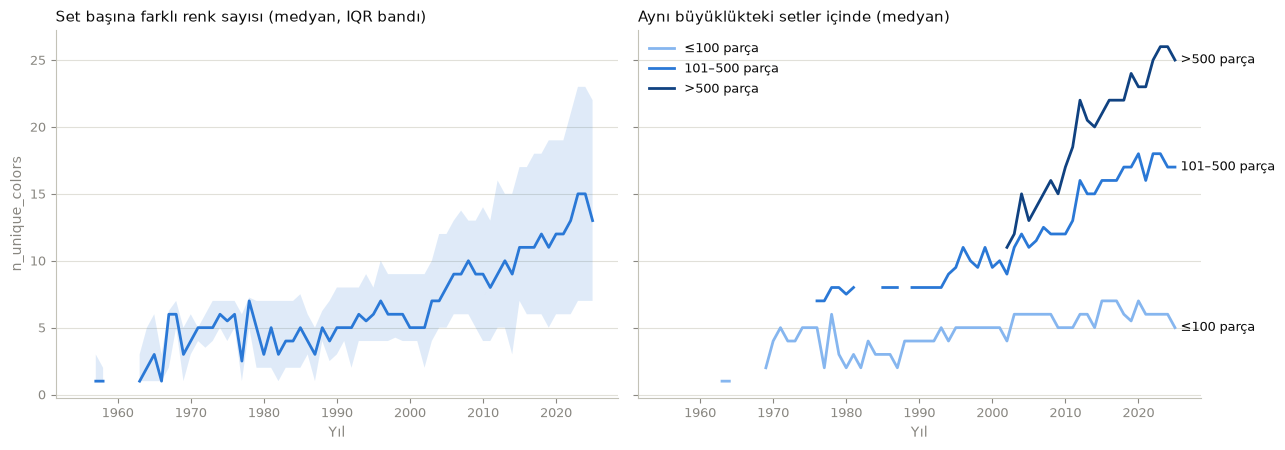

In [12]:
INK, MUTED, GRID, BASE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUE = "#2a78d6"
TIER_COLORS = dict(zip(size_labels, ["#86b6ef", "#2a78d6", "#104281"]))  # tek ton, sıralı (açık→koyu)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax in axes:
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(BASE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_xlabel("Yıl", color=MUTED)

ax = axes[0]
ax.fill_between(yearly.index, yearly["q1"], yearly["q3"], color=BLUE, alpha=0.15, linewidth=0)
ax.plot(yearly.index, yearly["median"], color=BLUE, linewidth=2)
ax.set_title("Set başına farklı renk sayısı (medyan, IQR bandı)", color=INK, fontsize=11, loc="left")
ax.set_ylabel("n_unique_colors", color=MUTED)

ax = axes[1]
for tier in size_labels:
    d = tier_yearly[tier_yearly["size_tier"] == tier].set_index("year")["median"]
    last_year = d.index.max()
    d = d.reindex(range(d.index.min(), last_year + 1))  # 20'den az setli yıllar çizgide boşluk olarak kalır
    ax.plot(d.index, d.values, color=TIER_COLORS[tier], linewidth=2, label=tier)
    ax.annotate(tier, (last_year, d.loc[last_year]), xytext=(4, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
ax.set_title("Aynı büyüklükteki setler içinde (medyan)", color=INK, fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="upper left")

fig.tight_layout()
plt.show()

In [13]:
decade = (eda["year"] // 10 * 10).rename("decade")
eda.groupby([decade, "size_tier"], observed=True)["n_unique_colors"].median().unstack().loc[1970:]

size_tier,≤100 parça,101–500 parça,>500 parça
decade,,,
1970,4.0,7.0,7.0
1980,3.0,8.0,9.0
1990,5.0,9.0,10.0
2000,5.0,11.0,14.0
2010,6.0,16.0,21.0
2020,6.0,17.0,25.0


In [14]:
print(f"Toplam çalışma: tepe bellek {peak_rss_mb():.0f} MB")

Toplam çalışma: tepe bellek 539 MB


## Özet

- **`data/processed/set_colors.csv`: 37.009 satır** — 19.787 gerçek set + 17.222 minifig (`fig-...`)
  envanteri. Minifig satırları bilerek tutuldu (ileride minifig renk analizi için); `sets_clean` ile
  join'de zaten düşüyorlar.
- **Eşleşme:** analiz-hazır 18.190 setin **18.018'i (%99,05)** renk verisine sahip. Eşleşmeyen 172
  setin hepsinin envanteri var ama kendi parça satırı yok — 167'si tek minifigürlük promosyon/mağaza
  setleri (parçaları minifig envanterinde).
- **Tutarlılık:** hiçbir sette `total_parts` `num_parts`'ı aşmıyor; minifigsiz setlerin %99,82'sinde
  birebir eşit. Minifig parçaları da eklendiğinde `num_parts` ile eşleşme %99,41 — §10'daki bulgu
  tüm veride tekrar doğrulandı.
- **Performans:** 133 MB'lık dosya 4 kolon + dar tiplerle ~0,35 sn'de, 17 MB bellekle okundu; tüm
  notebook ~540 MB tepe bellekle birkaç saniyede çalışıyor. Chunk'lı okumaya gerek olmadı.
- **Sınırlılık — minifig renkleri dahil değil:** minifig içeren setlerde minifig parçaları toplam
  parçaların yalnızca %4,2'si, ama **bu setlerin %86,6'sında renk sayısını artırıyorlar** (medyan +2
  renk). `n_unique_colors` bu setlerde sistematik olarak düşük; Bölüm 3'te minifig parçalarını dahil
  etmek düşünülmeli.
- **Sağlık kontrolü — kullanılabilir:** renk çeşitliliği zamanla belirgin şekilde artıyor
  (Spearman ρ = 0,43) ve bu, setlerin büyümesinden ibaret değil: aynı büyüklük dilimi içinde de artış
  sürüyor (101–500 ve >500 parça: ρ = 0,56; ≤100 parça: ρ = 0,27). >500 parçalı setlerde medyan renk
  sayısı 2000'lerde 14'ten 2020'lerde 25'e çıkmış. Bölüm 3 için anlamlı bir sinyal var.